# Part 1

### Combined solution

In [ ]:
#< START_SOLUTION 1-3 >
!python part_1_viola_jones_solution.py
#< END_SOLUTION 1-3 >

# Part 2

### Complete solution for Part 2: 


In [ ]:
#< START_SOLUTION 4-10 >
!python part_2_viola_jones_snapchat_solutions.py
#< END_SOLUTION 4-10 >

Optimized solution for Part 2:

In [ ]:

#< START_SOLUTION 11 >
!python part_2_viola_jones_snapchat_solutions_optim.py
#< END_SOLUTION 11 >

### Exercise 4

REMOVED TAGS FROM ALL SUBSEQUENT SNAPCHAT EXERCISES (review with Max)

In [ ]:
def load_png_object(file_path: str) -> Tuple[np.ndarray, Tuple[int, int, int]]:
    """
    Loads a png object as RGBA. Note, the .png should have a transparent background and be loaded with an alpha channel

    Args:
        file_path (str): relative path to the .png file 

    Returns:
        Tuple[np.ndarray, Tuple[int, int, int]]: the image array of shape (H, W, C) and a tuple (H, W, C) where C=4 for RGBA image 
    """

    im = cv2.imread(file_path,cv2.IMREAD_UNCHANGED)
    im_dims = im.shape 
    
    print(f"loaded object: {file_path} with shape: {im_dims}")
    return im, im_dims

### Exercise 5

In [ ]:
def assign_eyes(coords: np.ndarray) -> tuple[np.ndarray,np.ndarray]:
    """
    Assign left and right eye based on location in frame

    Args:
        eye_coords (np.ndarray): eye coordinate array where each row corresponds to x,y centre coordinates, shape (N, 2) (in current implementation of main loop, N=2)

    Returns:
        tuple[np.ndarray,np.ndarray]: left eye centre coordinates, right eye centre coordinates
    """
    #Example solution: 
    right_eye_idx = np.argmax(coords[:,0]) #actually we should use the pair which has the maximal horizontal distance
    right_eye = coords[right_eye_idx,:]
    left_eye = coords[1-right_eye_idx,:]

    if left_eye[0] > right_eye[0]:
        left_eye, right_eye = right_eye, left_eye
    
    return left_eye, right_eye


### Exercise 6

In [ ]:
"""
Solution exercise 6: find the normalized normal vector
"""
if N_eyes==2:
    (...stuff from earlier...) 
    vec = right_eye - left_eye
    ###find the normal vector - to find the translation we need  
    n_vec = np.array([-vec[1],vec[0]])
    norm = np.linalg.norm(n_vec)

    if norm == 0:  #becomes zero if the same eye is detected twice - we can't place a hat then
        print("Warning: zero-length eye vector, skipping hat placement")
        N_skipped += 1
    else: #normal vector has a length - continue with hat placement
        n_vec = n_vec/norm #normalize normal-vector 

### Exercise 7

In [ ]:
if N_eyes==2:
    (...stuff from earlier...)
    if norm == 0:  #becomes zero if the same eye is detected twice - we can't place a hat then
        print("Warning: zero-length eye vector, skipping hat placement")
        N_skipped += 1
    else: #normal vector has a length - continue with hat placement
        n_vec = n_vec/norm #normalize normal-vector 
        """
        Solution exercise 7: calculate the end-points of the hat, i.e. where it should be placed in the image
        """
        end_point_hat_x = int(face_center[0] - n_vec[0]*w//2)
        end_point_hat_y = int(face_center[1] - n_vec[1]*h//2) #subtract because image coordinate system 
        
        cv2.circle(frame,(end_point_hat_x,end_point_hat_y),10, color=(0,255,0),thickness=3, lineType=8, shift=0) #blue circle - top of face 
        cv2.line(frame,tuple(face_center),(end_point_hat_x,end_point_hat_y),color=(255, 0, 0 )) #green line                    

### Exercise 8

In [ ]:
"""
Exercise 8: rescale size such that it fits the head-width 
"""

def rescale_object(object_im: np.ndarray, face_width: int) -> np.ndarray: 
    """
    Rescales the object image to a specific width so it can match face width. 

    Args:
        object_im (np.ndarray): object image, shape (H,W,C)
        face_width (int): the detected face width

    Returns:
        np.ndarray: the rescaled object image

    """
    """
    Solution exercise 8: change the width_scale_factor such that the function adaptively fits the object onto the head
    """
    width_scale_factor = face_width/object_im.shape[1]
    out_im = rescale(object_im, width_scale_factor,channel_axis=-1, order=1)
    return out_im
    

object_im_trf = rescale_object(object_im, w+100) #finish the implementation of this function



### Exercise 9

In [ ]:
"""
Solution exercise 9: define the coordinates for alignment in the local hat coordinate frame
"""
#anchor point calculation: bottom centre of hat 
anchor_point = np.array([object_im_trf.shape[0]-1,object_im_trf.shape[1]//2]) #y,x format 

     

### Exercise 10

In [ ]:
if ROTATE:      
"""
Solution exercise 10: calculate the rotation angle which the hat should be rotated.
""" 
theta = np.arctan2(-vec[1],vec[0]) #is in radians
theta *= 180/np.pi 
object_im_trf, anchor_point_new, dx, dy = rotate_object(object_im_trf, theta, anchor_point, allow_resize=False) #get the corresponding anchor point after applying rotation
#TODO: somehow anchor_point_new needs to be part of the transform when allow_resize=True, but it seems okay-ish
anchor_point[0] = anchor_point[0] - dy 
anchor_point[1] = anchor_point[1] - dx



# Part 3

### Exercise 13

In [ ]:
#< START_SOLUTION 13 >
#inside the loop one can find the corner coordinates
x1, y1 = x0 + w, y0 + h
print(f"Upper left corner: {x0,y0}, Lower right corner: {x1,y1}")
#< END_SOLUTION 13 >


### Exercise 14

#< START_SOLUTION 14 >
All stage 0 features are especially well-suited for detecting vertical text and gaps between text (vertical edges), and are placed somewhat in the middle of the window.

Stage 1, feature 0 is perfectly suited for detecting angled (bright) edges, and seems to be somewhat local, possibly detecting angled boundaries of letters S, O or P. 

Stage 1, feature 1 is a global feature. It would become high-valued if there is a "darker" sign within a brighter background, and low-valued if there is a bright region in the middle and darker regions at the boundary of the window.

Similarily, stage 1, feature 2 would be well-suited for detecting bright text in the middle of a dark sign, producing low / negative values.

#< END_SOLUTION 14 >

### Exercise 15 

#< START_SOLUTION 15 >
Increasing the scale-factor achieves larger FPS. This is due to the lower number of windows in the window pyramid. But increaseing the scale-factor too much makes it impossible to detect small instances (i.e. signs at large distances). Thus, too large scale factor increases the False Negative Rate. Decreasing it to values closer to 1 dramatically reduces the FPS-performance, while decreasing the False Negative Rate. But in some cases, this may increase the False Positive Rate as well, as there is a larger chance for a false positive evaluation at some level in the window pyramid. 

The value 1.072 works well for **van_video.mp4**, whereas the value 1.015 somewhat works well for **scale_diff.mp4**.

In the case for **scale_diff.mp4**, there will always be a couple of false negative frames. 
The persistent False Negatives (e.g. frames 8-10) in scale_diff.mp4 are likely due to spatial quantization and a limited training dataset. Even with a small scale factor of 1.015, the detector creates a discrete 'ladder' of search windows. As the sign moves smoothly in 3D space, its projection on the 2D sensor passes through scales that do not perfectly align with the model's rigid Haar-feature geometry.

Furthermore, since the model was trained on a limited dataset, it lacks 'generalization', as it likely requires very specific and localized contrast matches to pass all cascade stages. When the sign is scaled to a size that forces pixel interpolation (blurring the edges), the mathematical sum of the Haar rectangles falls below the stage threshold, causing the cascade to reject the window, resulting in fewer detections. This can in some cases be alleviated by reducing the minimum number of neighbors necessary for a detection. 

#< END_SOLUTION 15 >

# Part 4

### Exercise 16

#< START_SOLUTION 16 >

In the following, we'll take a deeper look at what the model sees when computing a Haar feature. We'll both get more comfortable with what an integral image is and also how it's employed to produce fast computation of large image slices.


In [1]:

import os 

import matplotlib.pyplot as plt
import numpy as np
from skimage import io
from skimage.color import rgb2gray
from skimage.util import img_as_ubyte


### Loading and displaying the Haar images 

We'll start by loading both the reference and a computed Haar stage image.

In [4]:
# Load both the stage image and the reference image
feat_dir = 'data/haar_features'
img_path = os.path.join(feat_dir, 'stage_3.png')
stage_img = io.imread(img_path)
ref_path = 'data/annotation_img.jpg'
ref_img = io.imread(ref_path)
ref_img = img_as_ubyte(rgb2gray(ref_img)) # Want the image to be grayscaled

# Look at the stage image shape
print(stage_img.shape)

(240, 1200)



We find, that the images have been upscaled by x10 (240x1200) // 10 -> (24x24x5). Slicing according to our chosen feature and resizing, we get:

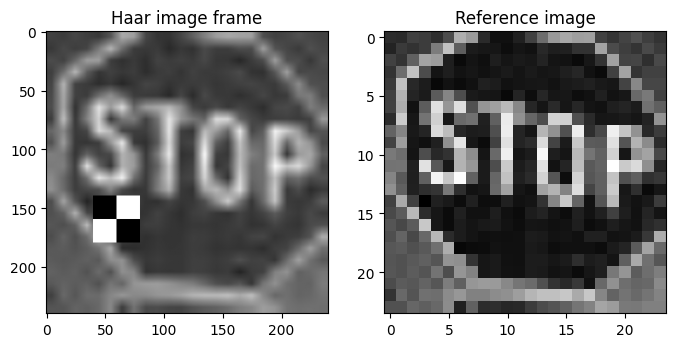

In [ ]:
# Rescale image down to w_window x h_window
w_enlargened, h_enlargened = (stage_img.shape[0],stage_img.shape[0])
ROI_feat = 2
ROI_img = stage_img[:, ROI_feat*w_enlargened:(ROI_feat+1)*w_enlargened]

_, axes = plt.subplots(ncols=2, figsize=(8,8))

axes[0].imshow(ROI_img, cmap='gray')
axes[0].set_title('Haar image frame')
axes[1].imshow(ref_img, cmap='gray')
axes[1].set_title('Reference image')
plt.show()



We now want to zoom in to the region of interest. Looking at the image histogram for the feature image, this gives us some hints.



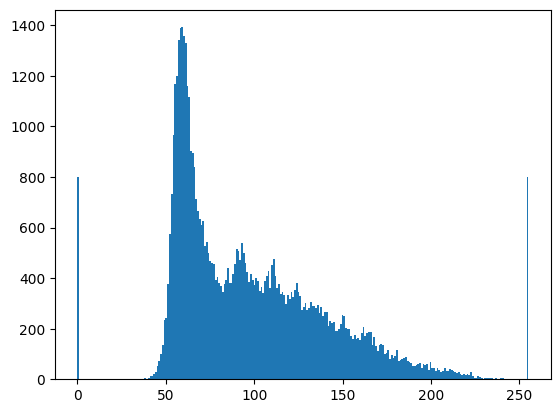

In [7]:
plt.hist(ROI_img.ravel(), bins=256)
plt.show()

Two very clear spikes form at 0 and 255, which incidentally are also the pixels we'd like to mask. Now, we find the coordinates of this area and scale them back to the actual 

In [ ]:
ys, xs = np.where((ROI_img == 0) | (ROI_img == 255))
coords = np.vstack((ys, xs)) # ys,xs due to standard convention of packages

# Get (y0,x0) and (y1,x1), slice and show image
ymin, xmin, ymax, xmax = np.concatenate((coords.min(axis=1), coords.max(axis=1)))

#now convert back to reference image by taking scale into account
y_min_ref, y_max_ref = ymin//10,ymax//10
x_min_ref, x_max_ref = xmin//10,xmax//10
print(y_min_ref, y_max_ref, x_min_ref, x_max_ref)

14 17 4 7


Notice, we choose to append an extra border layer, in order to effectively compute the Haar feature, as it depends on values outside of the bounding box. This is only relevant if we choose to use *np.cumsum* - if you use *cv2.integral* the border is zero padded.

#< END_SOLUTION 16 >


### Exercise 17: Compute integral image

#< START_SOLUTION 17 >

Now we compute the integral image using *np.cumsum*. We then visualize 

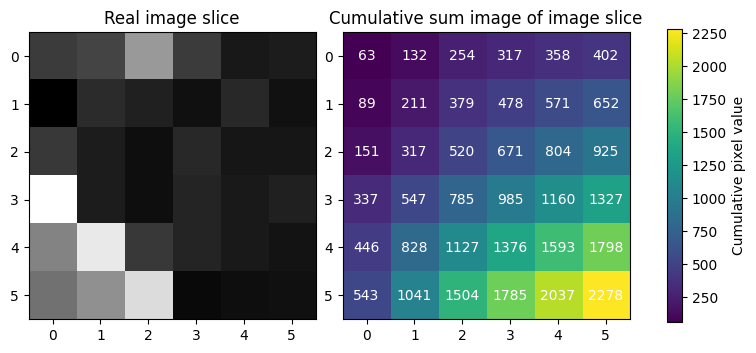

In [ ]:

# Retrieve sliced image
sliced_img = ref_img[y_min_ref-1:y_max_ref+2,x_min_ref-1:x_max_ref+2]

# Integral image options
# integral_img = cv2.integral(sliced_img)[1:,1:] # Pads boundary - hence we may remove the first row of y,x respectfully
integral_img = np.cumsum(np.cumsum(sliced_img, axis=0), axis=1)

# Visualize the sliced image along with its integral counterpart
fig, axes = plt.subplots(ncols=2, figsize=(8,8))
axes[0].imshow(sliced_img, cmap='gray')
axes[0].set_title('Real image slice')
axes[0].set_aspect('equal')
img = axes[1].imshow(integral_img, cmap='viridis')
axes[1].set_title('Cumulative sum image of image slice')
axes[1].set_aspect('equal')

# Write numbers on each pixel of cumsum image to gain extra insights
for (i, j), val in np.ndenumerate(integral_img):
    axes[1].text(j, i, f"{val}", ha='center', va='center', color='white', fontsize=10)

plt.tight_layout()
fig.colorbar(img, label='Cumulative pixel value', ax=axes, shrink=0.38)
plt.show()

#< END_SOLUTION 17 >


### Exercise 18: Computing Haar features
#< START_SOLUTION 18 >

We're now ready to compute our Haar feature. We first need to separate Haar regions accordingly. In our case, we're working with a four rectangle diagonal Haar feature, where each rectangle is a square of side-length 2. We can find the corresponding starting positions (top left corner) of each rectangle as below:

In [ ]:
# Retrieve w, h of the Haar regions
w, h = integral_img.shape[1], integral_img.shape[0]
w_rec, h_rec = w//2, h//2

# As regions are standard uniform, we may retrieve start positions of each region like:
start_positions = np.array([
    [(y, x) for x in np.linspace(start=1, stop=w_rec, num=2)]
    for y in np.linspace(start=1, stop=h_rec, num=2)]
).reshape(-1, 2)

print(start_positions)

[[1. 1.]
 [1. 3.]
 [3. 1.]
 [3. 3.]]


Now, we'll add some functions, that will help locate the corners of each Haar region, compute their individual summed area and finally compute the 4 region Haar feature.

In [20]:
def compute_integral_image(integral_img, y0, x0, w, h):
    """
        Computes the integral image within the bounding box represented by (y0,x0,w,h).

        :param numpy.ndarray integral_img:      The integral image input. Dimensions need to supercede those of the bounding box.
        :param int y0:                          Initial starting y position of bounding box.
        :param int x0:                          Initial starting x position of bounding box.
        :param int w:                           Width of bounding box.
        :param int h:                           Height of bounding box.
    """
    
    # Retrieve corners of bounding box
    pos1, pos2, pos3, pos4 = (y0-1, x0-1), (y0-1, x0-1+w-1),(y0-1+h-1, x0-1), (y0-1+h-1, x0-1+w-1)

    # Compute integral image
    A = integral_img[pos1[0], pos1[1]]
    B = integral_img[pos2[0], pos2[1]]
    C = integral_img[pos3[0], pos3[1]]
    D = integral_img[pos4[0], pos4[1]]
    return D + A - B - C

def compute_diagonal_feat(integral_img, start_positions, w_reg, h_reg):
    """
        Computes the diagonal Haar feature of a 
    """

    # Compute integral image for each square region
    regions = []
    for y,x in start_positions:
        reg_integral = compute_integral_image(integral_img, int(y), int(x), w_reg, h_reg)
        regions.append(reg_integral)
   
    # Compute Haar feature
    white_pixels = regions[1] + regions[2]
    black_pixels = regions[0] + regions[3]
    haar_feat =  white_pixels - black_pixels

    return haar_feat


Using the function, we can compute the value of the Haar feature.

In [ ]:
haar_feat = compute_diagonal_feat(integral_img, start_positions, w_rec, h_rec)
print(f"The computed Haar feature of image slice = {haar_feat}")
#< END_SOLUTION 18 >


The computed Haar feature of image slice = 132


### Exercise 19: Haar feature interpretation
#< START_SOLUTION 19 >
We notice that the filter has strong responses for angled (45 degree) edges. The most extreme negative values are produced in the S-letter, which makes sense as the "dark" filter regions exactly align with the high-intensity region of the S, and the "white" filter regions exactly align with the low-intensity sign-background. 
Similarly, large values are produced

The largest value is produced for pixel (10,4), where the white regions of the filter are exactly aligned with the bright parts of the "S", whereas the dark diagonal is low-intensity. 

We notice largely negative values when white regions are aligned with the white border of the 45 degree slopes, and strong positive values when offset around the 45 degree border. If we look at -45 degree slopes, it is reversed. 

The filter is zero in regions which have constant intensity or which have equal average diagonal intensities (i.e. no diagonal gradient). 

#< END_SOLUTION 19 >


# Part 5: Training your own object detector (Optional)

Solutions given directly in the given text.